# **LIDA Smart Composting: Forecasting & Automation (LSTM + Classifiers)**

**Goals**
1. Forecast next-hour compost confitions (temperatures, moisture, oxygen).
2. Predict optimal ventilation (**aeration_on**) from current state.
3. Detect **phase transition** readiness (active -> curing -> mature).
4. Provide a simple, rule-based control loop that can be swapped for MPC

**Data**
- File: `ideal_data_final.csv` (~60 days hourly = 1440 rows)
- Key Columns:
`list the features`

In [182]:
# imports
import os, math
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix, roc_auc_score, precision_recall_fscore_support

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Paths
DATA_PATH = "ideal_data_final.csv"

# sequence settings
WINDOW = 24 # hours of lookback
HORIZON = 3 # predict 1 hour ahead


In [183]:
# load & inspect data
df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
display(df.head(3))
print(df.dtypes)

shape: (1440, 18)


,timestamp,hour,phase,temperature_active1,temperature_active2,temperature_active3,temperature_active4,temperature_curing1,temperature_curing2,moisture_active1,moisture_active2,moisture_curing1,moisture_curing2,oxygen,co2,methane,methane_ppm,aeration_on
0,2025-01-01 00:00:00,0,active,34.81,35.74,34.17,35.25,31.69,32.64,58.05,59.93,44.78,45.51,8.80,0.00,0.0,0.0,1
1,2025-01-01 01:00:00,1,active,34.57,35.93,34.27,35.40,31.59,32.64,58.12,60.05,44.75,45.53,8.14,0.01,0.0,0.0,0
2,2025-01-01 02:00:00,2,active,34.89,35.61,34.24,35.11,31.53,32.63,57.92,60.22,44.84,45.59,8.27,0.01,0.0,0.0,0


timestamp               object
hour                     int64
phase                   object
temperature_active1    float64
temperature_active2    float64
temperature_active3    float64
temperature_active4    float64
temperature_curing1    float64
temperature_curing2    float64
moisture_active1       float64
moisture_active2       float64
moisture_curing1       float64
moisture_curing2       float64
oxygen                 float64
co2                    float64
methane                float64
methane_ppm            float64
aeration_on              int64
dtype: object


In [184]:
# basic cleaning: parse timestamp, sort time, phase as cateogory
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.sort_values('timestamp').reset_index(drop=True)

# ensure numeric for sensors (in case of stray strings)
numeric_cols = [
    'hour',
    'temperature_active1', 'temperature_active2', 'temperature_active3', 'temperature_active4',
    'temperature_curing1', 'temperature_curing2',
    'moisture_active1', 'moisture_active2', 'moisture_curing1', 'moisture_curing2', 
    'oxygen', 'co2', 'methane', 'methane_ppm',
    'aeration_on'
]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# handle any missing numeric by forward/back fill (dataset is ideal but just hardening for actual dataset)
df[numeric_cols] = df[numeric_cols].interpolate().bfill().ffill()

# phase to categorical data (keep a copy as string for exports)
df['phase'] = df['phase'].astype('category')
df['phase_str'] = df['phase'].astype(str)

display(df.head(3))

,timestamp,hour,phase,temperature_active1,temperature_active2,temperature_active3,temperature_active4,temperature_curing1,temperature_curing2,moisture_active1,moisture_active2,moisture_curing1,moisture_curing2,oxygen,co2,methane,methane_ppm,aeration_on,phase_str
0,2025-01-01 00:00:00,0,active,34.81,35.74,34.17,35.25,31.69,32.64,58.05,59.93,44.78,45.51,8.80,0.00,0.0,0.0,1,active
1,2025-01-01 01:00:00,1,active,34.57,35.93,34.27,35.40,31.59,32.64,58.12,60.05,44.75,45.53,8.14,0.01,0.0,0.0,0,active
2,2025-01-01 02:00:00,2,active,34.89,35.61,34.24,35.11,31.53,32.63,57.92,60.22,44.84,45.59,8.27,0.01,0.0,0.0,0,active


In [185]:
# feature engineering
sensor_cols = [
    'temperature_active1', 'temperature_active2', 'temperature_active3', 'temperature_active4',
    'temperature_curing1', 'temperature_curing2',
    'moisture_active1', 'moisture_active2', 'moisture_curing1', 'moisture_curing2', 
    'oxygen', 'co2', 'methane', 'methane_ppm',
]

# labs (1..6 hours)
LAGS = [1, 2, 3, 4, 5, 6]
for col in sensor_cols + ['aeration_on']:
    for L in LAGS:
        df[f'{col}_lag{L}'] = df[col].shift(L)

# rolling means (3, 6, 12 hours)
ROLLS = [3, 6, 12]
for col in sensor_cols:
    for R in ROLLS:
        df[f'{col}_roll{R}'] = df[col].rolling(R, min_periods=1).mean()

# deltas (first difference)
for col in sensor_cols:
    df[f'{col}_delta'] = df[col].diff()


# targets for forecasting: next-hour values
forecast_targets=[
    'temperature_active1', 'temperature_active2', 'temperature_active3', 'temperature_active4',
    'temperature_curing1', 'temperature_curing2',
    'moisture_active1', 'moisture_active2', 'moisture_curing1', 'moisture_curing2', 
    'oxygen'
]

for tgt in forecast_targets:
    df[f'{tgt}_tplus{HORIZON}'] = df[tgt].shift(-HORIZON)


# drop initial rows with NaNs due to lab/rolling
df_fe = df.dropna().reset_index(drop=True)
print("after FE:", df_fe.shape)
display(df_fe.head(2))

after FE: (1431, 176)


/var/folders/mp/5j6y5_ns2cx879p6y44k_6000000gn/T/ipykernel_34755/422786055.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag{L}'] = df[col].shift(L)
/var/folders/mp/5j6y5_ns2cx879p6y44k_6000000gn/T/ipykernel_34755/422786055.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag{L}'] = df[col].shift(L)
/var/folders/mp/5j6y5_ns2cx879p6y44k_6000000gn/T/ipykernel_34755/422786055.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, 

,timestamp,hour,phase,temperature_active1,temperature_active2,temperature_active3,temperature_active4,temperature_curing1,temperature_curing2,moisture_active1,moisture_active2,moisture_curing1,moisture_curing2,oxygen,co2,methane,methane_ppm,aeration_on,phase_str,temperature_active1_lag1,temperature_active1_lag2,temperature_active1_lag3,temperature_active1_lag4,temperature_active1_lag5,temperature_active1_lag6,temperature_active2_lag1,temperature_active2_lag2,temperature_active2_lag3,temperature_active2_lag4,temperature_active2_lag5,temperature_active2_lag6,temperature_active3_lag1,temperature_active3_lag2,temperature_active3_lag3,temperature_active3_lag4,temperature_active3_lag5,temperature_active3_lag6,temperature_active4_lag1,temperature_active4_lag2,temperature_active4_lag3,temperature_active4_lag4,temperature_active4_lag5,temperature_active4_lag6,temperature_curing1_lag1,temperature_curing1_lag2,temperature_curing1_lag3,temperature_curing1_lag4,temperature_curing1_lag5,temperature_curing1_lag6,temperature_curing2_lag1,temperature_curing2_lag2,temperature_curing2_lag3,temperature_curing2_lag4,temperature_curing2_lag5,temperature_curing2_lag6,moisture_active1_lag1,moisture_active1_lag2,moisture_active1_lag3,moisture_active1_lag4,moisture_active1_lag5,moisture_active1_lag6,moisture_active2_lag1,moisture_active2_lag2,moisture_active2_lag3,moisture_active2_lag4,moisture_active2_lag5,moisture_active2_lag6,moisture_curing1_lag1,moisture_curing1_lag2,moisture_curing1_lag3,moisture_curing1_lag4,moisture_curing1_lag5,moisture_curing1_lag6,moisture_curing2_lag1,moisture_curing2_lag2,moisture_curing2_lag3,moisture_curing2_lag4,moisture_curing2_lag5,moisture_curing2_lag6,oxygen_lag1,oxygen_lag2,oxygen_lag3,oxygen_lag4,oxygen_lag5,oxygen_lag6,co2_lag1,co2_lag2,co2_lag3,co2_lag4,co2_lag5,co2_lag6,methane_lag1,methane_lag2,methane_lag3,methane_lag4,methane_lag5,methane_lag6,methane_ppm_lag1,methane_ppm_lag2,methane_ppm_lag3,methane_ppm_lag4,methane_ppm_lag5,methane_ppm_lag6,aeration_on_lag1,aeration_on_lag2,aeration_on_lag3,aeration_on_lag4,aeration_on_lag5,aeration_on_lag6,temperature_active1_roll3,temperature_active1_roll6,temperature_active1_roll12,temperature_active2_roll3,temperature_active2_roll6,temperature_active2_roll12,temperature_active3_roll3,temperature_active3_roll6,temperature_active3_roll12,temperature_active4_roll3,temperature_active4_roll6,temperature_active4_roll12,temperature_curing1_roll3,temperature_curing1_roll6,temperature_curing1_roll12,temperature_curing2_roll3,temperature_curing2_roll6,temperature_curing2_roll12,moisture_active1_roll3,moisture_active1_roll6,moisture_active1_roll12,moisture_active2_roll3,moisture_active2_roll6,moisture_active2_roll12,moisture_curing1_roll3,moisture_curing1_roll6,moisture_curing1_roll12,moisture_curing2_roll3,moisture_curing2_roll6,moisture_curing2_roll12,oxygen_roll3,oxygen_roll6,oxygen_roll12,co2_roll3,co2_roll6,co2_roll12,methane_roll3,methane_roll6,methane_roll12,methane_ppm_roll3,methane_ppm_roll6,methane_ppm_roll12,temperature_active1_delta,temperature_active2_delta,temperature_active3_delta,temperature_active4_delta,temperature_curing1_delta,temperature_curing2_delta,moisture_active1_delta,moisture_active2_delta,moisture_curing1_delta,moisture_curing2_delta,oxygen_delta,co2_delta,methane_delta,methane_ppm_delta,temperature_active1_tplus3,temperature_active2_tplus3,temperature_active3_tplus3,temperature_active4_tplus3,temperature_curing1_tplus3,temperature_curing2_tplus3,moisture_active1_tplus3,moisture_active2_tplus3,moisture_curing1_tplus3,moisture_curing2_tplus3,oxygen_tplus3
0,2025-01-01 06:00:00,6,active,34.78,36.29,34.20,35.56,31.53,32.67,57.96,60.19,44.87,45.63,9.49,0.0,0.0,0.0,1,active,34.52,34.41,34.92,34.89,34.57,34.81,35.92,35.84,36.13,35.61,35.93,35.74,34.17,34.11,34.31,34.24,34.27,34.17,35.30,35.21,35.40,35.11,35.40,35.25,31.57,31.54,31.66,31.53,31.59,31.69,32.56,32.57,32.60,32.63,32.64,32.64,57.94,58.01,57.81,57.92,58.12,58.05,59.91,60.02,60.08,60.22,60.05,59.9

In [186]:
# train/val/test split by time
# time-based split (70% train, 15% val, 15% test)
N = len(df_fe)
train_end = int(0.7 * N)
val_end = int(0.85 * N)

df_train = df_fe.iloc[:train_end].copy()
df_val = df_fe.iloc[train_end:val_end].copy()
df_test = df_fe.iloc[val_end:].copy()

print(len(df_train), len(df_val), len(df_test))
print("train:", df_train['timestamp'].min(), "->", df_train['timestamp'].max())
print("val:", df_val['timestamp'].min(), "->", df_val['timestamp'].max())
print("test:", df_test['timestamp'].min(), "->", df_test['timestamp'].max())

1001 215 215
train: 2025-01-01 06:00:00 -> 2025-02-11 22:00:00
val: 2025-02-11 23:00:00 -> 2025-02-20 21:00:00
test: 2025-02-20 22:00:00 -> 2025-03-01 20:00:00


In [187]:
# helper to make windowed sequences for LSTM

# features for forecasting (exclue future targets and obcious leakage)
exclude_cols = set([c for c in df_fe.columns if c.endswith(f'_tplus{HORIZON}')])
exclude_cols |= {'timestamp', 'phase_str'} # keep categorical 'phase' separately

feature_cols_all = [c for c in df_fe.columns if c not in exclude_cols and c != 'phase' and c != 'aeration_on']
# adding 'phase via one-hot and 'aeration_on' as feature explicitly
feature_cols_all += ['aeration_on'] # current action matters
cat_cols = ['phase'] # one-hot later

# final target matrix cols
target_cols = [f'{t}_tplus{HORIZON}' for t in forecast_targets]

# one hot encode phase
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(df_train[cat_cols])

def add_phase_ohe(frame):
    mat = ohe.transform(frame[cat_cols])
    ohe_cols = [f'phase{c}' for c in ohe.categories_[0]]
    tmp = frame.copy()
    tmp[ohe_cols] = mat
    return tmp, ohe_cols

df_train_ohe, phase_ohe_cols = add_phase_ohe(df_train)
df_val_ohe, _ = add_phase_ohe(df_val)
df_test_ohe, _ = add_phase_ohe(df_test)

# build final feature list (add ohe cols)
feature_cols = feature_cols_all + phase_ohe_cols

# standardize features (fit on train, transform all)
scaler = StandardScaler()
scaler.fit(df_train_ohe[feature_cols])

def to_scaled(frame):
    X = scaler.transform(frame[feature_cols])
    y = frame[target_cols].values
    return X, y
Xtr, ytr = to_scaled(df_train_ohe)
Xva, yva = to_scaled(df_val_ohe)
Xte, yte = to_scaled(df_test_ohe)

#turn flat smaples into sequences (WINDOW time steps)
def make_sequences(X, y, window=24):
    Xs, ys = [], []
    for i in range(len(X) - window + 1):
        Xs.append(X[i:i+window, :])
        ys.append(y[i+window-1]) # predict t for the window's last point
    return np.array(Xs), np.array(ys)

Xtr_seq, ytr_seq = make_sequences(Xtr, ytr, WINDOW)
Xva_seq, yva_seq = make_sequences(Xva, yva, WINDOW)
Xte_seq, yte_seq = make_sequences(Xte, yte, WINDOW)

Xtr_seq.shape, ytr_seq.shape, Xva_seq.shape, yva_seq.shape, Xte_seq.shape, yte_seq.shape

((978, 24, 164),
 (978, 11),
 (192, 24, 164),
 (192, 11),
 (192, 24, 164),
 (192, 11))

In [ ]:
# LSTM model (multi-output regression)
tf.keras.backend.clear_session()

n_features = Xtr_seq.shape[-1]
n_targets = yte_seq.shape[-1]

model = models.Sequential([
    layers.Input(shape=(WINDOW, n_features)),
    layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3),
    layers.BatchNormalization(),
    layers.LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_targets)
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │       150,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         2,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,497 (806.63 KB)

 Trainable params: 206,113 (805.13 KB)

 Non-trainable params: 384 (1.50 KB)

In [200]:
# training

es = callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss')
rlr = callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-4, verbose=1)

history = model.fit(
    Xtr_seq, ytr_seq,
    validation_data=(Xva_seq, yva_seq),
    epochs=100,
    batch_size=128,
    callbacks=[es, rlr],
    verbose=1
)

pd.DataFrame(history.history).plot(figsize=(12,8))
plt.title("LSTM training history")
plt.show()

Epoch 1/100


ValueError: Dimensions must be equal, but are 11 and 33 for '{{node compile_loss/mse/sub}} = Sub[T=DT_FLOAT](data_1, sequential_1/dense_1_2/BiasAdd)' with input shapes: [?,11], [?,33].

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
LSTM forecast -> MAE: 1.419 | RMSE: 1.562 | R2: -45.412


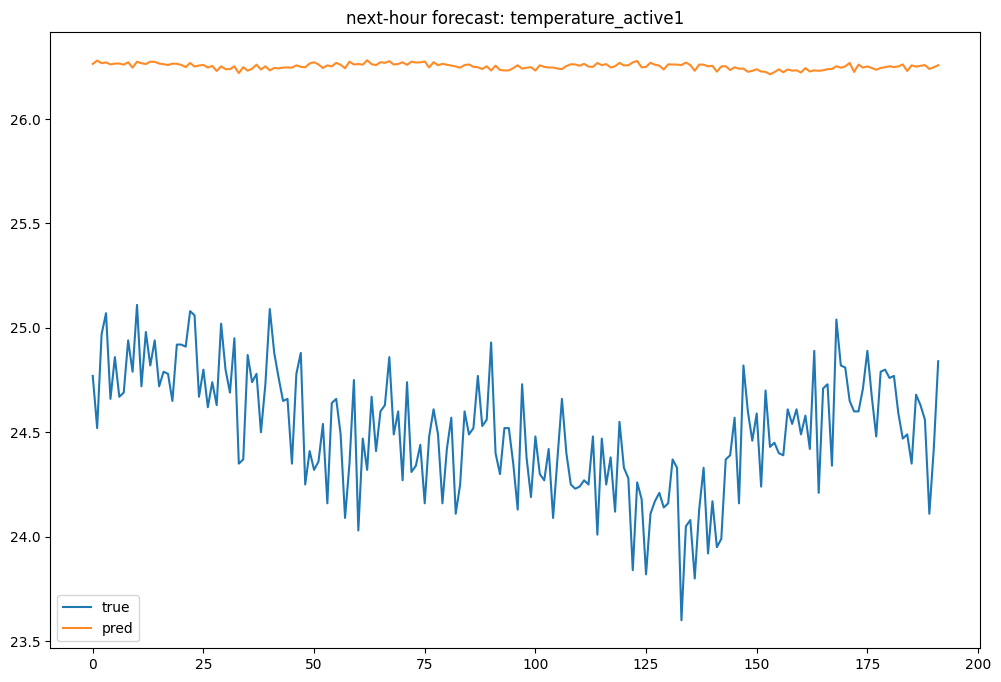

In [198]:
# evaluate on test
y_pred = model.predict(Xte_seq)
mae = mean_absolute_error(yte_seq, y_pred)
rmse = math.sqrt(mean_squared_error(yte_seq, y_pred))
r2 = r2_score(yte_seq, y_pred)

print(f"LSTM forecast -> MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}")

# plot one target vs prediction over a slice
target_to_plot = 'temperature_active1'
idx = forecast_targets.index(target_to_plot)
plt.figure(figsize=(12,8))
plt.plot(yte_seq[:200, idx], label='true')
plt.plot(y_pred[:200, idx], label='pred', alpha=0.9)
plt.title(f"next-hour forecast: {target_to_plot}")
plt.legend()
plt.show()

In [191]:
# --- Aeration control classifier (XGBoost) : predict next-hour action (no leakage, own scaler) ---

# 1) Label at t+1
df_lbl = df_fe.copy()
df_lbl['aeration_on_tplus1'] = df_lbl['aeration_on'].shift(-1)
df_lbl = df_lbl.dropna().reset_index(drop=True)

# 2) Ensure phase OHE columns exist with the SAME names you used during FE
#    (We reuse the fitted encoder `ohe` and your earlier phase_ohe_cols)
phase_mat = ohe.transform(df_lbl[['phase']])
df_lbl[phase_ohe_cols] = phase_mat

# 3) Build a LEAK-FREE feature list:
#    start from your earlier feature_cols, but DROP contemporaneous 'aeration_on'
safe_feat = [c for c in feature_cols if c != 'aeration_on']

# Sanity: make sure these columns exist
missing = [c for c in safe_feat if c not in df_lbl.columns]
if missing:
    raise KeyError(f"Missing features (compute before training): {missing[:10]} ...")

# 4) Time-ordered split
N = len(df_lbl)
tr_end = int(0.70 * N)
va_end = int(0.85 * N)
tr, va, te = df_lbl.iloc[:tr_end], df_lbl.iloc[tr_end:va_end], df_lbl.iloc[va_end:]

# 5) Fit a NEW scaler for THIS classifier on the leak-free features
scaler_cls = StandardScaler()
scaler_cls.fit(tr[safe_feat])

Xtr = scaler_cls.transform(tr[safe_feat])
Xva = scaler_cls.transform(va[safe_feat])
Xte = scaler_cls.transform(te[safe_feat])

ytr = tr['aeration_on_tplus1'].astype(int).values
yva = va['aeration_on_tplus1'].astype(int).values
yte = te['aeration_on_tplus1'].astype(int).values

# 6) Handle imbalance
pos_weight = (len(ytr) - ytr.sum()) / max(1, ytr.sum())
print(f"scale_pos_weight (train): {pos_weight:.3f}")

# 7) Train XGBoost
xgb_aer = XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=SEED,
    scale_pos_weight=pos_weight,
    eval_metric="auc",
)
xgb_aer.fit(
    Xtr, ytr,
    eval_set=[(Xva, yva)],
    verbose=False,
)

proba = xgb_aer.predict_proba(Xte)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("Aeration (t+1) — XGBoost")
print(classification_report(yte, pred, digits=3))
print("ROC-AUC:", roc_auc_score(yte, proba))
print("Confusion matrix:\n", confusion_matrix(yte, pred))


scale_pos_weight (train): 8.091
Aeration (t+1) — XGBoost
              precision    recall  f1-score   support

           0      0.916     1.000     0.956       197
           1      0.000     0.000     0.000        18

    accuracy                          0.916       215
   macro avg      0.458     0.500     0.478       215
weighted avg      0.840     0.916     0.876       215

ROC-AUC: 0.9052453468697124
Confusion matrix:
 [[197   0]
 [ 18   0]]


/Users/notvisal/Desktop/LIDA/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/notvisal/Desktop/LIDA/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/notvisal/Desktop/LIDA/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [192]:
# 10) Phase transition classifier (predict next phase) — NAME/ORDER MATCHED

# Build dataset with next-hour phase as target
for_split = df_fe.copy()
for_split['phase_next'] = for_split['phase_str'].shift(-1)
for_split = for_split.dropna().reset_index(drop=True)

# IMPORTANT: use the SAME OHE and SAME column names used earlier
# phase_ohe_cols already came from:
#   phase_ohe_cols = [f'phase{c}'] or [f'phase_{c}'] depending on your earlier code
# So we must create columns with EXACTLY those names:
mat = ohe.transform(for_split[['phase']])
for_split[phase_ohe_cols] = mat

# Use the EXACT feature list the scaler was fit on
# (this is the list you used to build the LSTM/classifier inputs earlier)
feat_cols_phase = feature_cols

# Sanity check: names must match 1:1 and in the same order
exp = list(getattr(scaler, 'feature_names_in_', []))
missing = [c for c in feat_cols_phase if c not in for_split.columns]
unexpected = [c for c in for_split.columns if c in exp and c not in feat_cols_phase]
if missing:
    raise ValueError(f"Missing columns in for_split that scaler expects: {missing[:10]} ...")
if exp and feat_cols_phase != exp:
    # Keep going, but warn if order differs
    print("⚠️ Warning: feature order differs from scaler.fit order. "
          "Attempting to reorder to match scaler expectations.")
    # Reorder to match scaler’s training order
    feat_cols_phase = exp

# Scale using the SAME scaler
X_phase = scaler.transform(for_split[feat_cols_phase])
y_phase = for_split['phase_next'].astype(str).values

# Time-wise split (70/15/15)
N2 = len(for_split)
tr_end2 = int(0.70 * N2)
va_end2 = int(0.85 * N2)

Xtr_p, Xva_p, Xte_p = X_phase[:tr_end2], X_phase[tr_end2:va_end2], X_phase[va_end2:]
ytr_p, yva_p, yte_p = y_phase[:tr_end2], y_phase[tr_end2:va_end2], y_phase[va_end2:]

# Train & evaluate baseline classifier

clf_phase = RandomForestClassifier(n_estimators=400, max_depth=12, random_state=SEED, n_jobs=-1)
clf_phase.fit(Xtr_p, ytr_p)

yhat_phase = clf_phase.predict(Xte_p)
print("Phase-next report:\n", classification_report(yte_p, yhat_phase, digits=3))
print("Confusion matrix:\n", confusion_matrix(yte_p, yhat_phase, labels=np.unique(y_phase)))
print("Classes:", np.unique(y_phase))


Phase-next report:
               precision    recall  f1-score   support

      curing      1.000     1.000     1.000       215

    accuracy                          1.000       215
   macro avg      1.000     1.000     1.000       215
weighted avg      1.000     1.000     1.000       215

Confusion matrix:
 [[  0   0]
 [  0 215]]
Classes: ['active' 'curing']


In [193]:
# 11) Simple control loop prototype
# Idea: use LSTM predictions for next-hour temp & oxygen, decide aeration_on

TEMP_HIGH = 65.0     # ℃ threshold to prevent overheating
OXY_LOW   = 7.0      # % oxygen threshold to replenish O2
TEMP_LOW  = 45.0     # too low (in active phase), may reduce aeration

def control_policy(pred_temp_mean, pred_oxygen, phase_name):
    # Very simple rules (replace with MPC later)
    if phase_name == 'active':
        if (pred_temp_mean > TEMP_HIGH) or (pred_oxygen < OXY_LOW):
            return 1  # turn on ventilation
        elif pred_temp_mean < TEMP_LOW:
            return 0  # keep off to retain heat
        else:
            return 0
    else:  # curing/matured typically cooler, less aeration
        if pred_temp_mean > (TEMP_HIGH - 5):
            return 1
        else:
            return 0

# Example usage on the first 200 test sequences
# Derive the phase for each sequence end point
phases_test = df_test_ohe['phase_str'].iloc[WINDOW-1:].head(len(yte_seq)).values  # align roughly
pred_temp_mean = y_pred[:, [forecast_targets.index('temperature_active1'),
                            forecast_targets.index('temperature_active2'),
                            forecast_targets.index('temperature_active3'),
                            forecast_targets.index('temperature_active4')]].mean(axis=1)
pred_oxygen = y_pred[:, forecast_targets.index('oxygen')]

actions = [control_policy(pred_temp_mean[i], pred_oxygen[i], phases_test[i]) for i in range(len(pred_temp_mean))]
print("Sample decided actions (0=off,1=on) for first 30 points:", actions[:30])


Sample decided actions (0=off,1=on) for first 30 points: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [194]:
# 12) Save artifacts for deployment (local files)
import joblib
SAVE_DIR = "./artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler.joblib"))
joblib.dump(ohe, os.path.join(SAVE_DIR, "phase_ohe.joblib"))
joblib.dump(clf, os.path.join(SAVE_DIR, "aeration_xgb.joblib"))
joblib.dump(clf_phase, os.path.join(SAVE_DIR, "phase_rf.joblib"))
model.save(os.path.join(SAVE_DIR, "lstm_forecaster.keras"))

print("Saved to:", os.listdir(SAVE_DIR))


Saved to: ['scaler.joblib', 'aeration_xgb.joblib', 'lstm_forecaster.keras', 'phase_ohe.joblib', 'phase_rf.joblib']


In [195]:
def realtime_forecast_and_action(window_df: pd.DataFrame):
    """
    window_df: last WINDOW rows from the *feature-engineered* dataframe (e.g., df_fe),
               so it already includes lags/rolls/deltas and 'aeration_on' etc.
    Returns: (pred_dict, action_int)
    """
    # Copy to avoid side effects
    tmp = window_df.copy()

    # 1) Ensure the same OHE columns the scaler expects (NO UNDERSCORES if that's how you trained)
    #    We rely on previously-fitted `ohe` and the exact names in `phase_ohe_cols`.
    #    Example: phase_ohe_cols == ['phaseactive', 'phasecuring']  (no underscore)
    mat = ohe.transform(tmp[['phase']])
    tmp[phase_ohe_cols] = mat

    # 2) Build the feature list EXACTLY as used for training the scaler
    #    feature_cols is the list you used before fitting the scaler
    feat_cols = list(feature_cols)

    # If the scaler exposes feature_names_in_, prefer that exact order
    if hasattr(scaler, "feature_names_in_"):
        # sanity: same set of columns?
        missing = [c for c in scaler.feature_names_in_ if c not in tmp.columns]
        extra   = [c for c in feat_cols if c not in scaler.feature_names_in_]
        if missing:
            raise KeyError(f"Realtime missing required features for scaler: {missing[:10]} ...")
        if extra:
            # Not fatal, but these won't be used; scaler only uses what it was fit on
            pass
        feat_cols = list(scaler.feature_names_in_)  # enforce exact order

    # 3) Transform features
    X_win = scaler.transform(tmp[feat_cols])

    # 4) Sequence batch of size 1 (assumes window_df has exactly WINDOW rows)
    if len(tmp) != WINDOW:
        raise ValueError(f"realtime_forecast_and_action expects exactly WINDOW={WINDOW} rows, got {len(tmp)}.")
    X_seq = np.expand_dims(X_win, axis=0)

    # 5) Forecast next-hour multi-targets
    y_hat = model.predict(X_seq, verbose=0)[0]

    # 6) Map outputs to a dict using your forecast_targets + HORIZON
    pred = {f'{forecast_targets[i]}_tplus{HORIZON}': y_hat[i] for i in range(len(forecast_targets))}

    # 7) Simple control decision (same policy as before)
    phase_name = tmp['phase_str'].iloc[-1]

    # mean of active temps (use those that exist in forecast_targets)
    active_t_targets = [t for t in ['temperature_active1','temperature_active2','temperature_active3','temperature_active4']
                        if t in forecast_targets]
    pred_temp_mean = float(np.mean([pred[f'{t}_tplus{HORIZON}'] for t in active_t_targets]))
    pred_oxygen    = float(pred[f'oxygen_tplus{HORIZON}'])

    action = control_policy(pred_temp_mean, pred_oxygen, phase_name)
    return pred, int(action)


In [196]:
# Now call with engineered rows (must include lags/rolls/deltas):
last_window = df_fe.head(WINDOW).copy()
p, a = realtime_forecast_and_action(last_window)
print(p)
print("Action:", a)

{'temperature_active1_tplus3': np.float32(39.822857), 'temperature_active2_tplus3': np.float32(40.41625), 'temperature_active3_tplus3': np.float32(37.47417), 'temperature_active4_tplus3': np.float32(38.251358), 'temperature_curing1_tplus3': np.float32(26.158815), 'temperature_curing2_tplus3': np.float32(27.248854), 'moisture_active1_tplus3': np.float32(49.988453), 'moisture_active2_tplus3': np.float32(53.15285), 'moisture_curing1_tplus3': np.float32(37.656242), 'moisture_curing2_tplus3': np.float32(38.126007), 'oxygen_tplus3': np.float32(7.5549273)}
Action: 0
